In [37]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular

Preprocess data


In [16]:
weather = pd.read_csv("dataset/kl_weather_openmeteo.csv")
sensor = pd.read_csv("dataset/sensor_data_extended.csv")

data_combined = pd.concat([
    weather[['datetime', 'temperature', 'humidity']],
    sensor[['mic_level', 'mq2_raw']]
], axis=1)

data_combined.head()

,datetime,temperature,humidity,mic_level,mq2_raw
0,2020-01-01 00:00:00,26.2,82,566.0,614.0
1,2020-01-01 01:00:00,25.6,83,560.0,607.0
2,2020-01-01 02:00:00,25.0,86,562.0,613.0
3,2020-01-01 03:00:00,24.7,86,562.0,608.0
4,2020-01-01 04:00:00,24.3,87,566.0,618.0


In [17]:
# --- 1. Prepare (once, using data_combined directly) ---
data_combined['datetime'] = pd.to_datetime(data_combined['datetime'])
data_combined = data_combined.sort_values('datetime').reset_index(drop=True)

# --- 2. Features & Scaling ---
features = ['temperature', 'humidity', 'mic_level', 'mq2_raw']
X = data_combined[features].copy().fillna(data_combined[features].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)
model.fit(X_scaled)

data_combined['anomaly']       = model.predict(X_scaled)       # 1=normal, -1=anomaly
data_combined['anomaly_score'] = model.score_samples(X_scaled) # lower = more anomalous

In [19]:
anomalies = data_combined[data_combined['anomaly'] == -1]
print(f"Anomalies: {len(anomalies)} / {len(data_combined)}")
print(anomalies[['datetime'] + features + ['anomaly_score']].head(10))

Anomalies: 877 / 43848
                datetime  temperature  humidity  mic_level  mq2_raw  \
567  2020-01-24 15:00:00         33.3        46      573.0    631.0   
568  2020-01-24 16:00:00         33.8        44      569.0    630.0   
569  2020-01-24 17:00:00         33.2        43      567.0    630.0   
592  2020-01-25 16:00:00         33.1        45      571.0    624.0   
1006 2020-02-11 22:00:00         26.5        84      344.0    483.0   
1008 2020-02-12 00:00:00         26.1        86      847.0    902.0   
1009 2020-02-12 01:00:00         26.4        83      864.0    913.0   
1010 2020-02-12 02:00:00         26.4        82      848.0    880.0   
1011 2020-02-12 03:00:00         26.0        83      792.0    806.0   
1012 2020-02-12 04:00:00         25.9        82      753.0    759.0   

      anomaly_score  
567       -0.620953  
568       -0.644165  
569       -0.638469  
592       -0.613898  
1006      -0.640943  
1008      -0.671213  
1009      -0.682859  
1010      -0.684699

In [50]:
temperature = 33.3
humidity    = 80
mic_level   = 573.0
mq2_raw     = 550.0


test_point  = np.array([[temperature, humidity, mic_level, mq2_raw]])
test_scaled = scaler.transform(test_point)
print(test_scaled)

pred     = model.predict(test_scaled)[0]
score    = model.score_samples(test_scaled)[0]
decision = model.decision_function(test_scaled)[0]

label = "ANOMALY" if pred == -1 else "Normal"

print(f"Result   : {label}")
print(f"Score    : {score:.4f}   (lower = more anomalous)")
print(f"Decision : {decision:.4f}  (negative = anomaly)")



[[  3.3  32.    2.5 -40. ]]
Result   : ANOMALY
Score    : -0.7167   (lower = more anomalous)
Decision : -0.1042  (negative = anomaly)


Point index : 0
Prediction  : Normal
Anomaly score: -0.3922

Feature contributions (+ = pushes toward anomaly):
  -0.03 < mq2_raw <= 0.62             -0.1220  ↓ normal
  -0.63 < mic_level <= -0.05          -0.0844  ↓ normal
  -0.82 < temperature <= -0.20        -0.0749  ↓ normal
  -0.61 < humidity <= 0.23            -0.0740  ↓ normal


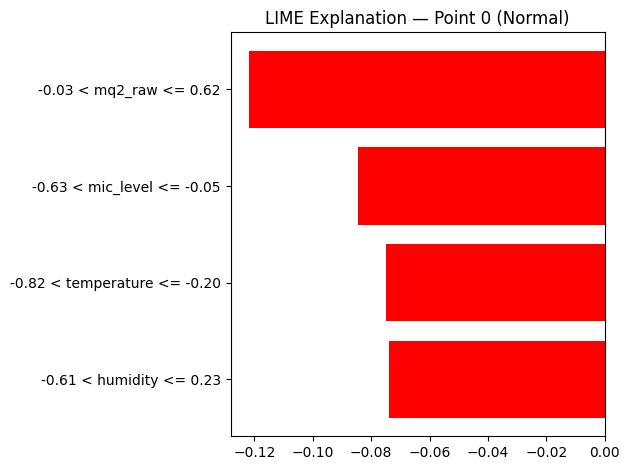

In [48]:
features = ['temperature', 'humidity', 'mic_level', 'mq2_raw']

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_scaled,
    feature_names   = features,
    mode            = 'classification',
    discretize_continuous = True,
    random_state    = 42
)


index = 0
test_point = X_scaled[index].reshape(1, -1)

def predict_fn(X):
    scores = model.score_samples(X)
    # Convert anomaly score to pseudo-probabilities [normal, anomaly]
    prob_anomaly = 1 - (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return np.column_stack([1 - prob_anomaly, prob_anomaly])

explanation = explainer.explain_instance(
    data_row        = X_scaled[index],
    predict_fn      = predict_fn,
    num_features    = 4,        # show all 4 features
    num_samples     = 1000      # higher = more stable explanation
)

pred  = model.predict(test_point)[0]
label = "ANOMALY" if pred == -1 else "Normal"

print(f"Point index : {index}")
print(f"Prediction  : {label}")
print(f"Anomaly score: {model.score_samples(test_point)[0]:.4f}")
print()
print("Feature contributions (+ = pushes toward anomaly):")
for feat, weight in explanation.as_list(label=1):
    direction = "↑ anomaly" if weight > 0 else "↓ normal"
    print(f"  {feat:<35} {weight:+.4f}  {direction}")

fig = explanation.as_pyplot_figure(label=1)
plt.title(f"LIME Explanation — Point {index} ({label})")
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150)
plt.show()

In [36]:
import joblib

joblib.dump(model,  'isolation_forest_model.pkl')
joblib.dump(scaler, 'isolation_forest_scaler.pkl')

print("Saved: isolation_forest_model.pkl")
print("Saved: isolation_forest_scaler.pkl")

Saved: isolation_forest_model.pkl
Saved: isolation_forest_scaler.pkl
